In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Data understanding
- The dataset contains 7 features or columns.
- These are age, sex, bmi, children, smoker, region, and charges (target).
- The age column exhibits the age of the primary beneficiary.A primary beneficiary is the person (or persons) first in line to receive the death benefit from your life insurance policy
- The sex column refers to the gender of the insurance contractor, whether male, female or other (if any)
- The bmi column refers to the As Per Body Mas index.
- The children column informs us about the number of children covered in the insurance policy.
- The smoker columns tells about the smoking attitude.
- The region column referes to the area from where the beneficiary belongs
- The charges column tells us about the individual medical costs billed by health insurance.

# Content covered in the notebook
- Data Cleaning
- Exloratory Data Analysis
- Hypothesis Testing
- Regression Models
- Feature Engineering
- Hyperparameter Tuning

In [ ]:
# installing modules
!pip install outlier_utils

# imporing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from outliers import smirnov_grubbs as grubbs
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# loading the dataset
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

In [ ]:
# checking the dataset
df.head()

In [ ]:
# getting info about the data types, data shape and null values present in it or etc
df.info()

In [ ]:
# getting basic statistics for the data
df.describe()

- The age, bmi, children these columns have nearly the same mean and median but the mean and median for charges column vary greatly which suggests either outliers are skewing the mean or actually some large bills were covered.

# Data Cleaning

In [ ]:
# checking for null values in the dataset
df.isna().sum()

- No null values are spotted.


In [ ]:
# checking for duplicates in the dataset
df[df.duplicated()]

- One duplicate value is spotted let's check it if it's actually the case.

In [ ]:
df[(df["age"] == 19) & (df["sex"] == "male") & (df["bmi"] == 30.59) & (df["region"] == "northwest")]

- So, I did subsetting of the data and found that it is actually a duplicate.

In [ ]:
# removing the duplicate value from the data
print("Shape of data before removing the duplicate {}".format(df.shape))
df = df.drop_duplicates()
print("-" * 53)
print("Shape of data after removing the duplicate {}".format(df.shape))

In [ ]:
# now let's detect outliers in the numerical columns
num_col = ["age","bmi","charges"]
for col in num_col:
    plt.style.use("ggplot")
    sns.boxplot(df[col])
    plt.title("Detection of outliers in {} using boxplot".format(col))
    plt.show()
#

### Interpretation of boxplots
- The boxplot of age column showed that there are no outliers
- The boxplot of bmi column showed that there are some outliers, but I will not remove them because a person can have 53 bmi which is the maximum bmi of the column.
- The boxplot of charges column shows a lot of outliers, but I will not remove them as such expenses can be covered by the insurance policy.

- We can perform hypothesis test to determine whether the outliers spotted are actual outliers or not.

# Grubbs test to detect outliers
- Grubbs’ Test is also known as the maximum normalized residual test or extreme studentized deviate test is a test used to detect outliers in a univariate data set assumed to come from a normally distributed population. This test is defined for the hypothesis:

- H0: There are no outliers in the data set
- H1: There is exactly one outlier in the data

- The grubs test takes input and returns output free of outliers, so I will perform grubs test on bmi and charges column.

In [ ]:
# perform Grubbs' test
outlier_columns = ["bmi","charges"]
for col in outlier_columns:
    df[col] = grubbs.test(df[col],alpha=0.05)


In [ ]:
# checking for the null values
df.isna().sum()

In [ ]:
# replacing the null value in charges column by the median
df["charges"].fillna(df["charges"].median(),inplace=True)

In [ ]:
# checking for null values again
df.isna().sum()

# Exploratory data analysis

### Univariate Analysis

### Categorical

In [ ]:
# plotting a pie chart to see distribution of gender
sizes = df["sex"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.title("Pie chart showing distribution of sex")
plt.show()

In [ ]:
# Checking frequency of number of children
sns.countplot(x="children",data=df,palette="viridis")
plt.title("Analyzing frequency occurence of children")
plt.xlabel("Number of Children")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
# plotting a pie chart to see distribution of gender
sizes = df["smoker"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Pie chart showing distribution of smokers and non-smokers")
plt.axis('equal')
plt.legend(["yes = smoker","no = non-smoker"])
plt.show()

- The perosn's who smoke are more in number than those who do not.

In [ ]:
# plotting a pie chart to see distribution of region
sizes = df["region"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Pie chart showing distribution of different regions")
plt.axis('equal')
# plt.legend(["yes = smoker","no = non-smoker"])
plt.show()

- The pie chart shows that most beneficiaries belong to southeast region and rest does not have any major difference.

# Numerical

In [ ]:
# Seeing how the numerical columns are distributed
sns.histplot(x="age",data=df,kde=True)
plt.title("Analyzing distribution of age column")
plt.show()

- The hisplot of age column is showin large counts at 19-21 and rest of the plot suggesting nearly equal  counts for the values.

# Shapiro Wilk Test
- It test whether a data sample has a normal distribution. Applying shapiro wilk test on the age column for the determination of gaussian distribution 

### Assumptions
1) Observations in each sample are independent and identically distributed (iid)
2) Interpretation

H0: The age has Gaussian Normal Distribution
H1: The age does not have a Gaussian/Normal Distribution


In [ ]:
from scipy.stats import shapiro
data = df["age"]
stats,p = shapiro(data)
if p > 0.05:
    print(round(p,3))
    print("Distribution is normal")
else:
    print(round(p,3))
    print("Distribution is not normal")

- The shapiro wilk test resulted in the conclusion that the distribution of age is not normal

In [ ]:
# Seeing how the numerical columns are distributed
sns.histplot(x="bmi",data=df,kde=True)
plt.title("Analyzing distribution of bmi column")
plt.show()

- The histplot of bmi column shows that the distribution is normal with a little skewness to the right.

In [ ]:
# Seeing how the numerical columns are distributed
sns.histplot(x="charges",data=df,kde=True)
plt.title("Analyzing distribution of charges column")
plt.show()

- The histplot of charges column shows that it does not follows a normal distribution and it has two humps and it is skewed to the right extremly

# Bivariate Analysis
- Analysis will be done for the target column charges

# Sex and Charges

In [ ]:
sns.barplot(x="sex",y="charges",data=df,ci=False)
plt.title("Average charges billed for genders")
plt.show()

- The barplot is suggesting that the average charges billed for male and female is different

In [ ]:
sns.kdeplot(x="charges",data=df,hue="sex")
plt.title("Analyzing distribution of charges for different genders")
plt.show()

- The above plots are suggesting a difference. We can apply a t-test to determine whether this difference is significant or not.

# Parametric Statistical Hypothesis Test
### 1-Student's t-test 
Test whether the means of two independent samples are significantlly different

### Interpretation

- H0 : The means of the two sample (charges for male and female) are equal
- H1 : The means of the two sample (charges for male and female) are not equal


In [ ]:
male_charge = df[df["sex"] == "male"]["charges"]
female_charge = df[df["sex"] == "female"]["charges"]

stat,p = ttest_ind(male_charge,female_charge)
if p > 0.05:
    print("P-value is {}".format(p))
    print("We cannot reject the null hypothesis, there is no diference in average charges billed for male and female")
else:
    print("P-value is {}".format(p))
    print("We can reject the null hypothesis, there is diference in average charges billed for male and female")

# Smoker and Charges

In [ ]:
sns.barplot(x="smoker",y="charges",data=df,ci=False)
plt.title("Average charges billed for smokers and non-smokers")
plt.show()

In [ ]:
sns.kdeplot(x="charges",data=df,hue="smoker")
plt.title("Distribution of charges billed regarding smoker or not")
plt.show()

- The above plots are suggesting a difference in the charges billed for smoker and non-smoker. We can apply a t-test to determine whether this difference is significant or not.

# Parametric Statistical Hypothesis Test
### 1-Student's t-test 
Test whether the means of two independent samples are significantlly different

### Interpretation

- H0 : The means of the two sample (charges for smoker and non-smoker) are equal. The average billed charges for smoker is not greater than the non-smoker.
- H1 : The mean of billed charges for smokers is greater than the averag charges billed for non-smokers.

- Applying one sided (greater) t-test.


In [ ]:
smoker_charge = df[df["smoker"] == "yes"]["charges"]
non_smoker_charge = df[df["smoker"] == "no"]["charges"]

stat,p = ttest_ind(smoker_charge,non_smoker_charge,alternative="greater")
if p > 0.05:
    print("P-value is {}".format(p))
    print("We cannot reject the null hypothesis, the average billing for smoker is not greater than the non-smoker")
else:
    print("P-value is {}".format(p))
    print("We can reject the null hypothesis, the average billing for smoker is greater than the non-smoker")

- So, after applying the t-test I conclude that the billing covered for smoker is greater as compared to non-smoker.

In [ ]:
sns.barplot(x="sex",y="bmi",data=df,ci=False,palette="Blues")
plt.title("Average BMI for gender")
plt.show()

In [ ]:
sns.kdeplot(x="bmi",data=df,hue="sex")
plt.title("Distribution of bmi for male and female")
plt.show()

- From the barplot and kde plot the difference of bmi for male and female seem to be non-significant, we can confirm this non-significance by using a statistical test.

# Parametric Statistical Hypothesis Test
### 1-Student's t-test 
Test whether the means of two independent samples are significantlly different

### Interpretation

- H0 : The means of the bmi level for male and female is equal. 
- H1 : The mean of bmi level for male and female is not equal



In [ ]:
male_bmi = df[df["sex"] == "male"]["bmi"]
female_bmi = df[df["sex"] == "female"]["bmi"]

stat,p = ttest_ind(male_bmi,female_bmi)
if p > 0.05:
    print("P-value is {}".format(p))
    print("We cannot reject the null hypothesis, the average bmi level for male and female is same")
else:
    print("P-value is {}".format(p))
    print("We can reject the null hypothesis, the average bmi level for male and female is not same")

In [ ]:
sns.barplot(x="smoker",y="bmi",data=df,ci=False,palette="Blues")
plt.title("Average BMI for smoker and non-smoker")
plt.show()

In [ ]:
sns.kdeplot(x="bmi",data=df,hue="smoker")
plt.title("Distribution of bmi for smoker and non-smoker")
plt.show()

# Parametric Statistical Hypothesis Test
### 1-Student's t-test 
Test whether the means of two independent samples are significantlly different

### Interpretation

- H0 : The mean of the bmi level for smoker and non-smoker is equal. 
- H1 : The mean of bmi level for smoker and non-smoker is not equal


In [ ]:
smoker_bmi = df[df["smoker"] == "yes"]["bmi"]
non_smoker_bmi = df[df["smoker"] == "no"]["bmi"]

stat,p = ttest_ind(smoker_bmi,non_smoker_bmi)
if p > 0.05:
    print("P-value is {}".format(p))
    print("We cannot reject the null hypothesis, the average bmi level for smoker and non-smoker is same")
else:
    print("P-value is {}".format(p))
    print("We can reject the null hypothesis, the average bmi level for smoker and non-smoker is not same")

In [ ]:
sns.barplot(x="children",y="charges",data=df,ci=False)
plt.title("Average charges billed having different number of children")
plt.show()

In [ ]:
sns.kdeplot(x="charges",data=df,hue="children",palette="viridis")
plt.title("Distribution of charges billed regarding # of children")
plt.show()

- The plots are suggesting different averages of billed charges and different distributions for number of children. We can confirm it by applying statistical test. 


- We will use ANOVA test to determine statistical significance of difference.As there are 6 different samples we are going to apply a ANOVA which stands for analysis of variance test.

# Analysis Of Variance Test (ANOVA) 
Test whether the means of two or more independent samples are significantly different

### Interpretation

H0 : The means of the samples are equal

H1 : One or more of the means of the samples are unequal

In [ ]:
from scipy.stats import f_oneway
no_children = df[df["children"] == 0]["charges"]
one_children = df[df["children"] == 1]["charges"]
two_children = df[df["children"] == 2]["charges"]
three_children = df[df["children"] == 3]["charges"]
four_children = df[df["children"] == 4]["charges"]
five_children = df[df["children"] == 5]["charges"]
stat,p = f_oneway(no_children,one_children,two_children,three_children,four_children,five_children)
if p > 0.05:
    print("We cannot reject the null hypothesis. The average billing  is not different for all samples")
else:
    print("We can reject the null hypothesis. The average billing is different for samples")

In [ ]:
sns.barplot(x="region",y="charges",data=df,ci=False)
plt.title("Average charges covered for different regions")
plt.show()

In [ ]:
sns.kdeplot(x="charges",data=df,hue="region",palette="viridis")
plt.title("Distribution of charges covered for different regions")
plt.show()

- The plots are suggesting different averages for charges covered and different distributions for charges covered for different regions. We can confirm it by applying statistical test. 


- We will use ANOVA test to determine statistical significance of difference.As there are 4 different regions we are going to apply a ANOVA which stands for analysis of variance test.

# Analysis Of Variance Test (ANOVA) 
Test whether the means of two or more independent samples are significantly different

### Interpretation

H0 : The average charges covered for different regions is same

H1 : The average charges covered for different regions is not same

In [ ]:
from scipy.stats import f_oneway
southwest = df[df["region"] == "southwest"]["charges"]
southeast = df[df["region"] == "southeast"]["charges"]
northwest = df[df["region"] == "northwest"]["charges"]
northeast = df[df["region"] == "northeast"]["charges"]

stat,p = f_oneway(southwest,southeast,northwest,northeast)
if p > 0.05:
    print("We cannot reject the null hypothesis. The average charges covered for different regions is same")
else:
    print("We can reject the null hypothesis. The average charges covered for different regions is not same")

In [ ]:
sns.scatterplot(x="age",y="charges",data=df)
plt.title("Analyzing relationship between age and charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

- The scatterplot is showing 3 different trends, but all 3 suggest positive correlation. We can apply statistical test to see if correlation exists.

# Correlation Test
### Pearson's Correlation Coefficient
- Test whether two samples have a linear relationship

H0 : The age and charges are independent
H1 : There is a dependency between the age and charges

In [ ]:
age = df["age"]
charges = df["charges"]
stat,p = pearsonr(age,charges)
if p > 0.05:
    print(p)
    print("We cannot reject the null hypothesis. Age and charges are not dependent and have no linear relationship")
else:
    print(p)
    print("We can reject the null hypothesis. Age and charges are dependent and have linear relationship")

In [ ]:
sns.scatterplot(x="bmi",y="charges",data=df,alpha=0.4)
plt.title("Analyzing relationship between bmi and charges covered")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

- The scatterplot is showing positive correlation. But, we can apply statistical tests to confirm it.

# Correlation Test
### Pearson's Correlation Coefficient
- Test whether two samples have a linear relationship

- H0 : The bmi and charges are independent
- H1 : There is a dependency between bmi and charges

In [ ]:
bmi = df["bmi"]
charges = df["charges"]
stat,p = pearsonr(bmi,charges)
if p > 0.05:
    print(p)
    print("We cannot reject the null hypothesis. BMI and charges are not dependent and have no linear relationship")
else:
    print(p)
    print("We can reject the null hypothesis. BMI and charges are dependent and have linear relationship")

In [ ]:
# checking correlation among variables of the data
corr = df.corr()

sns.heatmap(corr,annot=True,fmt=".2f")
plt.title("Correlation among variables")
plt.show()

- The heatmap of correlation shows that the age and bmi are correlated to the charges but this correlation is not very strong.

# Multivariate Analysis

In [ ]:
sns.barplot(x="sex",y="charges",data=df,hue="smoker",ci=False)
plt.title("Determining charges covered for male & female smoker or non-smoker")
plt.show()

- in both genders average charges covered for smokers are more than non-smokers 

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x="sex",y="charges",data=df,hue="region",ci=False)
plt.title("Determining charges covered for male & female smoker or non-smoker")
plt.legend(loc=("upper right"))
plt.show()

- In both genders the average most billing covered is in southeast region, but least vary in both. For females the average least billing is covered in southwest region and for male the least billing is covered in northwest region.

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="age",y="charges",data=df,hue="sex")
plt.title("Relationship of age and charges by sex")
plt.show()

- The scatterplot of age vs charges hued by sex shows that the charges covered tends to rise up with the increase in age level.

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="bmi",y="charges",data=df,hue="sex",alpha=0.4)
plt.title("Relationship of bmi and charges by sex")
plt.show()

- The scatterplot of bmi vs charges hued by sex shows that the charges covered tends to rise up with the increase in bmi level.

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x="sex",y="bmi",data=df,hue="region",ci=False,palette="viridis")
plt.title("Average bmi for genders by region")
plt.legend(loc="upper right")
plt.show()

- The plot shows there is but not much difference in average bmi level for genders in different regions.

# Data Preparation for Machine Learning
- The machine learning algorithms understand only numerical data. In our dataset there are some categorical features which we need to convert into numerical, where each numeric number is a representative of a category. So, in this section we will prepare our data to be fed into machine learning algorithms

- The object columns are sex, smoker and region. We can replace the unique categorical values in them by integers, where each integer denotes a particular category in that column.

In [ ]:
# checking datatypes of columns
df.dtypes

In [ ]:
# converting another dataframe to avoid any wrangling mistakes
df2 = df.copy()

In [ ]:
# converting se column values male and female in 1 and 0, where male = 1 and female = 0
df2["sex"] = df2["sex"].replace("male",1)
df2["sex"] = df2["sex"].replace("female",0)

In [ ]:
# converting smoker column values, where 1 = yes and 0 - no
df2["smoker"] = df2["smoker"].replace("yes",1)
df2["smoker"] = df2["smoker"].replace("no",0)

In [ ]:
# converting region column, where southwest = 0, southeast = 1, northwest = 2 and northeast = 3
df2["region"] = df2["region"].replace("southwest",0)
df2["region"] = df2["region"].replace("southeast",1)
df2["region"] = df2["region"].replace("northwest",2)
df2["region"] = df2["region"].replace("northeast",3)

In [ ]:
# now checking the dtypes of df2 to ensure all column are numerical
df2.dtypes

# Machine Learning
- In the section of machine learning we will predict charges by using all the other features. The charges column is a numerical column. So, this machine learning problem is Regression problem which is a type of supervised machine learning 

- We will cover closed form equation that directly computes the model parameters that best fit the model to the training set.

- The regression problem we are going to tackle is a multiple regression as we will give more than one input to get a single output(charges). It is also a univariate regression problem as we are trying to predict a single value. The multivariate regression problem is used when we need to predict more than a single value.

# Linear Regression
- Linear regression analysis is used to predict the value of a variable based on the value of another variable. The variable you want to predict is called the dependent variable. The variable you are using to predict the other variable's value is called the independent variable.

- This form of analysis estimates the coefficients of the linear equation, involving one or more independent variables that best predict the value of the dependent variable. Linear regression fits a straight line or surface that minimizes the discrepancies between predicted and actual output values.


# Metrics for Performace Evaluation
- Following are the common metrics used to evaluate linear regression model performance.

### Root Mean Squared Error (RMSE)
- RMSE is the square root of the mean of the square of all of the error. RMSE is considered an excellent general-purpose error metric for numerical predictions. RMSE is a good measure of accuracy, but only to compare prediction errors of different models or model configurations for a particular variable and not between variables, as it is scale-dependent. It is the measure of how well a regression line fits the data points. The formula for calculating RMSE is:

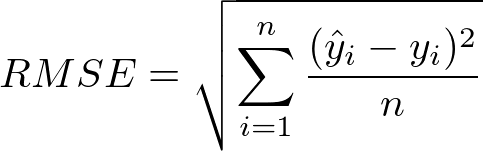
- yi^ = Predicted
- yi = Actual
- n = number of obervations

### Mean Absolute Error
- Mean Absolute Error calculates the average difference between the calculated values and actual values. It is also known as scale-dependent accuracy as it calculates error in observations taken on the same scale.It calculates errors between actual values and values predicted by the model. 
- Mean Absolute Error (MAE) is calculated by taking the summation of the absolute difference between the actual and calculated values of each observation over the entire array and then dividing the sum obtained by the number of observations in the array.

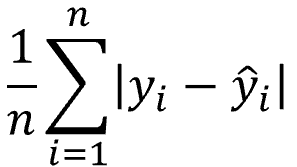

- yi = Actual value
- yi^ = predicted value
- n = number of observations

### R-squared error
- R-squared is a goodness of fit measure for linear regression models. This statistic indicates the percentage of the variance in the dependent variable that the independent variables explain collectively. R-squared measures the strength of the relationship between your model and the dependent variable on a convenient 0 – 100% scale. The more the R-squar value the greater the variance is explained by independent variables in the dependent variable

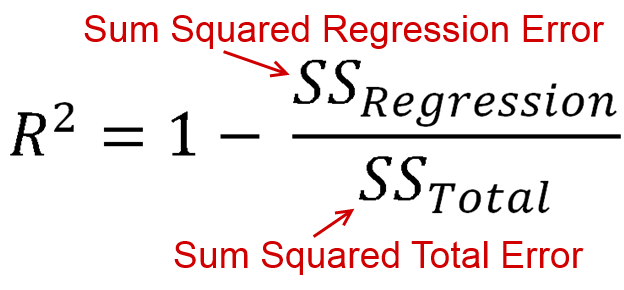







In [ ]:
# splitting data into features and target
X = df2.copy()
X.drop("charges",axis=1,inplace=True)
y = df2["charges"]

In [ ]:
# The data contain variables which have different scales so we are standardizing them.
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
# splitting data into training and test set
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=21)

In [ ]:
# making models to use
linreg = LinearRegression()
dtr = DecisionTreeRegressor()
rfr = RandomForestRegressor()
ridge = Ridge()
lasso = Lasso()

models = [linreg,dtr,rfr,ridge,lasso]
model_name = ["LinearRegression","DecisionTreeRegressor","RandomForestRegressor","Ridge","Lasso"]

average_rmse = []
average_r2_score = []
for model, name in zip(models,model_name):
    scores = ['neg_root_mean_squared_error',"r2"]
    cv_score_rmse = cross_val_score(model,X_train,y_train,cv=5,scoring = 'neg_root_mean_squared_error')
    cv_score_r2 = cross_val_score(model,X_train,y_train,cv=5,scoring = 'r2')
    average_rmse.append(np.mean(-1 * cv_score_rmse))
    average_r2_score.append(np.mean(cv_score_r2))
    print("RMSE scores of {} are {}".format(name,-1 * cv_score_rmse))
    print("R2 scores of {} are {}".format(name, cv_score_r2))
    #print("R2 score of {} are {}".format(name,cv_score))
    print("-" * 100)
    

In [ ]:
# visualizing RMSE
sns.barplot(x= model_name,y=average_rmse)
plt.title("Average RMSE of 5 fold cross validation for models")
plt.xticks(rotation=90)
plt.xlabel("Model Names")
plt.ylabel("RMSE")
plt.show()

- The barplot shows that RMSE for 5 fold cross validation is minimum for RandomForestRegressor. 

In [ ]:
sns.barplot(x= model_name,y=average_r2_score)
plt.title("Average R2 of 5 fold cross validation for models")
plt.xticks(rotation=90)
plt.xlabel("Model Names")
plt.ylabel("R2")
plt.show()

- The barplot shows that r2 score is maximumn for RandomForestRegressor. R2 score means how much of the variance in the target variable is being exlained by the features, the greater the r2 score the greater the variance is explained

# Feature Engineering
- I am going to engineer some features in the data and see if the model performance improves

In [ ]:
# i am going to categorize bmi column into normal,overweigth, obese or extremely obese
bins = [17, 24, 29, 39,54]
names = ['normal', 'over-weight', 'obese', 'extremely obese']

df2['bmi_cat'] = pd.cut(df2['bmi'], bins, labels=names)

In [ ]:
# checking for null values
df2.isna().sum()

In [ ]:
# replacing null values by the most frequent value
df2["bmi_cat"].fillna(df2["bmi_cat"].mode().values[0],inplace=True)

In [ ]:
# checking for null values again
df2.isna().sum()

In [ ]:
# convering categories of bmi_cat column into numerics
df2["bmi_cat"] = df2["bmi_cat"].replace("normal",0)
df2["bmi_cat"] = df2["bmi_cat"].replace("over-weight",1)
df2["bmi_cat"] = df2["bmi_cat"].replace("obese",2)
df2["bmi_cat"] = df2["bmi_cat"].replace("extremely obese",3)

In [ ]:
# getting features and scaling them
X2 = df2.copy()
X2.drop(["charges","bmi_cat"],axis=1,inplace=True)
X2_scaled = StandardScaler().fit_transform(X2)

In [ ]:
# splitting the data into training and test set
X2_train,X2_test,y_train,y_test = train_test_split(X2_scaled,y,test_size=0.2,random_state=21)

In [ ]:
# applying another random forest regressor on the data
rfr2 = RandomForestRegressor()

rfr2_cross_rmse = cross_val_score(rfr2,X2_train,y_train,cv=5,scoring="neg_root_mean_squared_error")
rfr2_cross_r2 = cross_val_score(rfr2,X2_train,y_train,cv=5,scoring="r2")
print("RMSE of RandomForestRegressor before feature engineering {}".format(average_rmse[2]))
print("RMSE of RandomForestRegressor before feature engineering {}".format(average_r2_score[2]))
print("-" * 74)
print("RMSE of RandomForestRegresor after feature engineering {}".format(np.mean(-1 * rfr2_cross_rmse)))
print("RMSE of RandomForestRegressor after feature engineering {}".format(np.mean(rfr2_cross_r2)))

- The categorization of bmi column does not seem to improve the model very much

# Hyperparameter tuning
- Hyperparameter tuning consists of finding a set of optimal hyperparameter values for a learning algorithm while applying this optimized algorithm to any data. That combination of hyperparameters maximizes the model's performance, minimizing a predefined loss function to produce better results with fewer errors.

In [ ]:
# I will perform grid search cv to tune parameters for the RandomForestRegressor
param = {"n_estimators":[100,200,300],"max_features":["sqrt","log2"],"oob_score":["True","False"]}
rfr = RandomForestRegressor()
grid_search = GridSearchCV(rfr,param_grid=param,cv=3,scoring='neg_root_mean_squared_error')

In [ ]:
# fitting the grid search on the training data
grid_search.fit(X_train,y_train)

In [ ]:
print("Tuned Random Forest Regressor Parameters: {}".format(grid_search.best_params_))
print("Best score is {}".format(-1 * grid_search.best_score_))

- Hyperparameter tuning slightly improved the model performance. Let's check it on the test set

In [ ]:
grid_ypred = grid_search.predict(X_test)
grid_search_rmse = metrics.mean_squared_error(y_test,grid_ypred)
print("RMSE of grid search on the test set is {}".format(np.sqrt(grid_search_rmse)))

- I trainned multiple regression models and evaluated their performances using two metrics RMSE (root mean squared error and r2 error). After evaluation I chosed the best one which is Random Forest Regressor and tuned it's parameter using the grid search cv.